# Gradient Descent Visualization
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Cost curve, the gradient descent update rule, learning rate effects, and a simple linear regression demo.

### Main goals:

- Plot a cost function and visualise gradient descent stepping toward the minimum.
- Compare too-small, good, and too-large learning rates.
- Implement gradient descent for single-variable linear regression and check the cost converges.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## A Simple Cost Curve

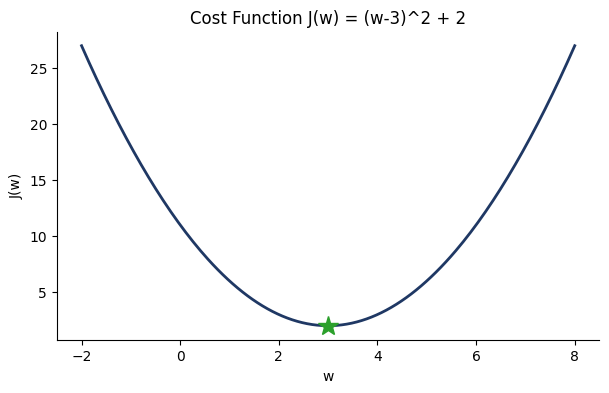

In [2]:
def cost(w):
    return (w - 3) ** 2 + 2

def gradient(w):
    return 2 * (w - 3)

w_range = np.linspace(-2, 8, 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_range, cost(w_range), color='#1F3864', lw=2)
ax.plot(3, cost(3), '*', color='#2CA02C', markersize=15)
ax.set_xlabel('w')
ax.set_ylabel('J(w)')
ax.set_title('Cost Function J(w) = (w-3)^2 + 2')
plt.show()

## Gradient Descent Steps

In [3]:
def run_gradient_descent(start_w, lr, n_iter):
    w = start_w
    history = [w]
    for _ in range(n_iter):
        w = w - lr * gradient(w)
        history.append(w)
    return history

history = run_gradient_descent(start_w=7.0, lr=0.2, n_iter=15)
print('Start:', history[0], ' Final:', round(history[-1], 4))

Start: 7.0  Final: 3.0019


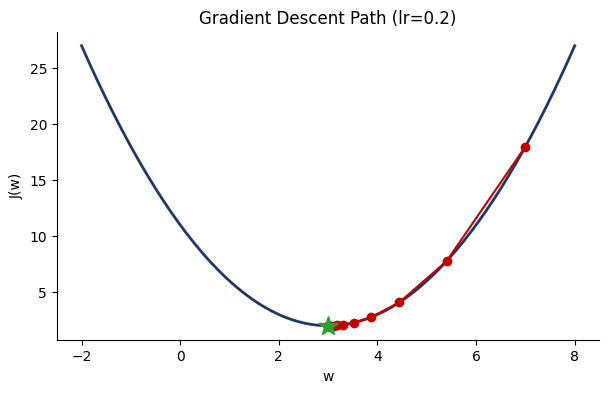

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_range, cost(w_range), color='#1F3864', lw=2)

history_costs = [cost(w) for w in history]
ax.plot(history, history_costs, 'o-', color='#C00000', markersize=6, lw=1.5)
ax.plot(3, cost(3), '*', color='#2CA02C', markersize=15)

ax.set_xlabel('w')
ax.set_ylabel('J(w)')
ax.set_title('Gradient Descent Path (lr=0.2)')
plt.show()

**Observation:**
Steps get smaller as `w` approaches the minimum, since the gradient itself shrinks closer to 0 there. Update size is not fixed, it scales with the slope.

## Learning Rate Comparison

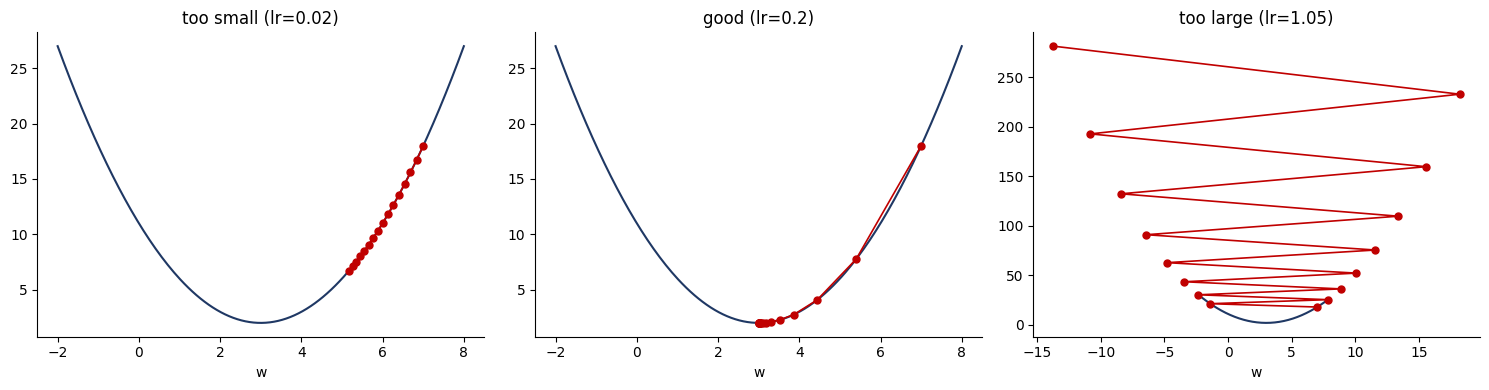

In [5]:
rates = {'too small (lr=0.02)': 0.02, 'good (lr=0.2)': 0.2, 'too large (lr=1.05)': 1.05}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, lr) in zip(axes, rates.items()):
    h = run_gradient_descent(start_w=7.0, lr=lr, n_iter=15)
    ax.plot(w_range, cost(w_range), color='#1F3864', lw=1.5)
    ax.plot(h, [cost(w) for w in h], 'o-', color='#C00000', markersize=5, lw=1.2)
    ax.set_title(label)
    ax.set_xlabel('w')

plt.tight_layout()
plt.show()

**Observation:**
`lr=0.02` barely moves in 15 steps. `lr=1.05` overshoots the minimum and diverges outward instead of converging — same mistake as in the from-scratch Linear Regression notebook in Week 4, where too high a learning rate made the cost increase instead of decrease.

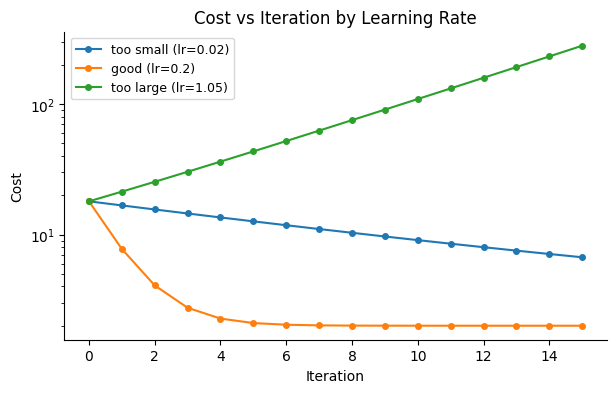

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, lr in rates.items():
    h = run_gradient_descent(start_w=7.0, lr=lr, n_iter=15)
    ax.plot(range(len(h)), [cost(w) for w in h], 'o-', label=label, markersize=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost')
ax.set_yscale('log')
ax.set_title('Cost vs Iteration by Learning Rate')
ax.legend(fontsize=9)
plt.show()

## Simple Linear Regression with Gradient Descent

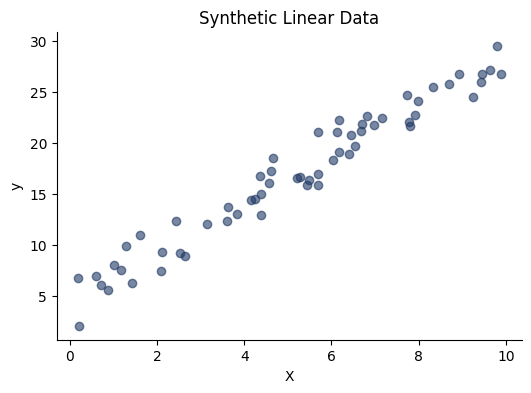

In [7]:
np.random.seed(0)
n = 60
X = np.random.uniform(0, 10, n)
true_w, true_b = 2.5, 4.0
y = true_w * X + true_b + np.random.normal(0, 1.5, n)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X, y, alpha=0.6, color='#1F3864')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Synthetic Linear Data')
plt.show()

In [8]:
def fit_linear_regression(X, y, lr=0.01, n_iter=1000):
    m = len(X)
    w, b = 0.0, 0.0
    cost_history = []

    for _ in range(n_iter):
        y_pred = w * X + b
        cost_history.append((1/m) * np.sum((y_pred - y) ** 2))

        dw = (2/m) * np.sum((y_pred - y) * X)
        db = (2/m) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

    return w, b, cost_history

w_fit, b_fit, cost_history = fit_linear_regression(X, y, lr=0.01, n_iter=1000)
print(f'True w={true_w}, b={true_b}')
print(f'Fitted w={w_fit:.4f}, b={b_fit:.4f}')

True w=2.5, b=4.0
Fitted w=2.4002, b=4.5587


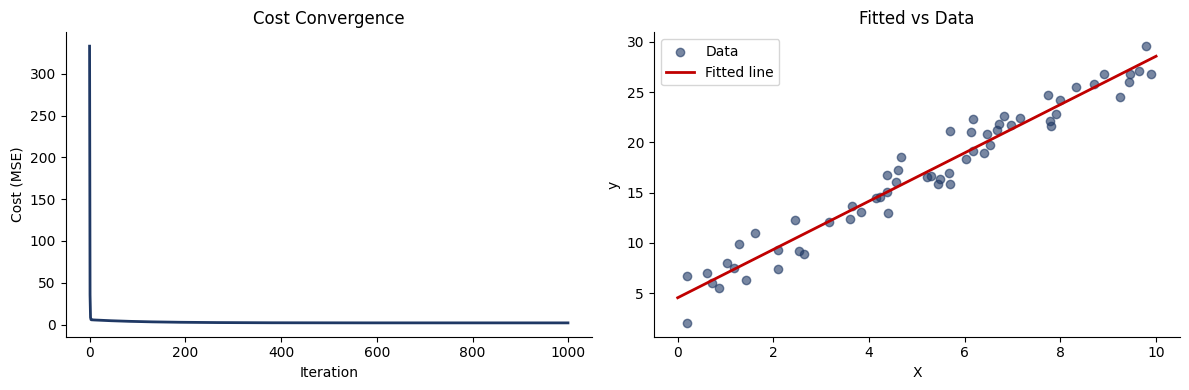

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cost_history, color='#1F3864', lw=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost (MSE)')
axes[0].set_title('Cost Convergence')

axes[1].scatter(X, y, alpha=0.6, color='#1F3864', label='Data')
x_line = np.linspace(0, 10, 50)
axes[1].plot(x_line, w_fit * x_line + b_fit, color='#C00000', lw=2, label='Fitted line')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('Fitted vs Data')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:**
Fitted `w` and `b` land close to the true values used to generate the data. Cost drops fast in the first ~100 iterations then flattens — most of the learning happens early.